## Notes

1. *When P is small, some datasets may not contain all 10 digits. I did not fix this because I don't think it is top priority as of June 21 2022*.

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import tqdm, utils, theory, data
from tabulate import tabulate
from numpy.linalg import inv as inv
import torch
import tqdm
import torch.nn.functional as F

%load_ext autoreload
%autoreload 2

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

P = 500; n_tasks = 5
depth = 1

NUM_SEEDS = 1


def r_ab(a, b, depth, inputs, temp=0):
    a = a - 1
    b = b - 1
    k_ab = theory.arccos_kernel_deep(inputs[a], inputs[b],
                                     var1=torch.ones(1), depth=depth)
    kb_inv = theory.inverse(theory.arccos_kernel_deep(inputs[b], inputs[b],
                                                      var1=torch.ones(1), depth=depth) + torch.eye(k_ab.shape[0]) * temp)
    return k_ab @ kb_inv


def r_rand(depth, inputs, temp=0):
    rand_task_inds = torch.randperm(len(inputs))
    a = rand_task_inds[0]
    b = rand_task_inds[1]
    return r_ab(a, b, depth, inputs, temp)


def get_simple_dataset(num_tasks, num_examples, dataset, resample, permutation, only_x = False):
    sigma = 0.2
    seq_of_train_x, _, seq_of_train_digits, _ =\
        data.prepare_sequential_dataset(num_tasks, num_examples, 1, dataset_name=dataset,
                                        resample=resample, permutation=permutation,
                                        data_path=None, n_epochs=1)

    # sort each training set such that the Y vectors are the same
    for i in range(num_tasks):
        seq_of_train_x[i] = seq_of_train_x[i][torch.argsort(seq_of_train_digits[i])]

    if only_x:
        return seq_of_train_x

    predictions_over_heads = torch.zeros((10, num_tasks, num_tasks, num_examples, 1))

    for head_ind in tqdm.trange(10):

        synced_seq_of_y =\
                torch.stack([data.digit_to_onehot(seq_of_train_digits[0]) for _i in range(num_tasks)])
        Y_vec = synced_seq_of_y[:, :, head_ind]  # only computing things for the first output head


        training_predictions, _ =\
                    theory.compute_mean_predictions(seq_of_train_x=seq_of_train_x,
                                                    seq_of_train_y=Y_vec,
                                                    w_var=sigma**2, P_test=1,
                                                    lambda_val=1e10,
                                                    seq_of_test_x=[None for _i in range(num_tasks)],
                                                    fix_weights=1, depth=depth)
        predictions_over_heads[head_ind] = training_predictions

    return seq_of_train_x, predictions_over_heads, synced_seq_of_y[0]


Yk_norms = torch.zeros((NUM_SEEDS, n_tasks, 10))
final_error = torch.zeros((NUM_SEEDS, n_tasks, 10))
for _seed in range(NUM_SEEDS):
    all_x, predictions, Y = get_simple_dataset(n_tasks, P, dataset='fashion', resample=False, permutation=1)
    for head_ind in range(10):
        for i in range(n_tasks):
            Yk_norms[_seed, i, head_ind] =\
                torch.norm(predictions[head_ind, i, i-1].flatten() - Y[:, head_ind].flatten())**2
            final_error[_seed, i, head_ind] =\
                torch.norm(predictions[head_ind, i, -1].flatten() - Y[:, head_ind].flatten())**2


/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 10/10 [00:00<00:00, 12.20it/s]


In [58]:
all_Y_tildes = torch.zeros((n_tasks, P, 1))
for i in range(n_tasks):
    all_Y_tildes[i] = Y[:, 3, :]


for i in range(1, n_tasks):
    for j in range(1, i):
        all_Y_tildes[i] -= r_rand(depth, all_x, 0) @ all_Y_tildes[j-1]

/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


In [83]:
mixed_x = all_x.reshape(-1, all_x.shape[-1])

/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


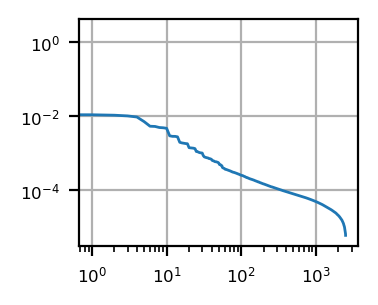

In [86]:
k_self = theory.arccos_kernel_deep(mixed_x, mixed_x, torch.ones(1), depth=10)
plt.figure()
u, s, v = torch.linalg.svd(k_self)
plt.plot(s)
plt.xscale('log')
plt.yscale('log')
plt.grid()

/Users/haozheshan/miniforge3/envs/m1pro/lib/python3.9/site-packages/matplotlib/axes/_base.py:2283: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


Text(0.5, 0, 'k')

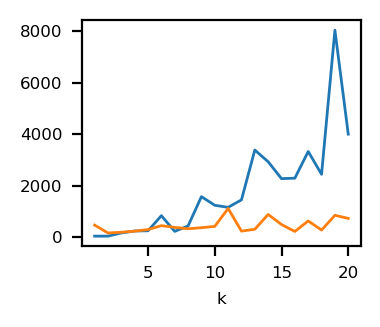

In [68]:
head_ind = 4
plt.figure()
plt.plot(range(1, n_tasks+1), torch.norm(all_Y_tildes.squeeze(), dim=1)**2)
plt.errorbar(range(1, n_tasks+1), Yk_norms[:, :, head_ind].mean(0), Yk_norms[:, :, head_ind].std(0))
plt.xlabel('k')

<ErrorbarContainer object of 3 artists>

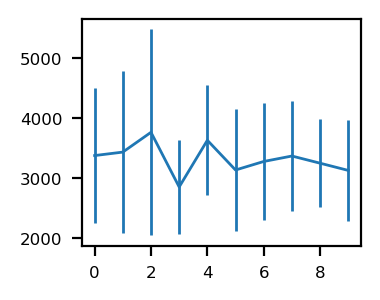

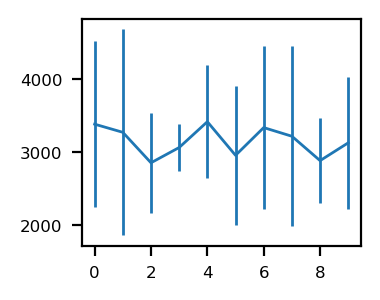

In [18]:
plt.figure()
plt.errorbar(range(n_tasks), Yk_norms.mean(0), Yk_norms.std(0))

plt.figure()
plt.errorbar(range(n_tasks), final_error.mean(0), final_error.std(0))

In [ ]:




R12 = r_ab(1, 2, depth, seq_of_train_x)
R21 = r_ab(2, 1, depth, seq_of_train_x)
R13 = r_ab(1, 3, depth, seq_of_train_x)
R32 = r_ab(3, 2, depth, seq_of_train_x)
R23 = r_ab(2, 3, depth, seq_of_train_x)
R14 = r_ab(1, 4, depth, seq_of_train_x)
R42 = r_ab(4, 2, depth, seq_of_train_x)
R43 = r_ab(4, 3, depth, seq_of_train_x)



R12_full = R12 @ (torch.eye(P) - R21)
R12_3_full = (R12 - R13 @ R32) @ (torch.eye(P) - R21)
R12_43_full = (R12 - R13 @ R32 - R14 @ (R42 - R43 @ R32)) @ (torch.eye(P) - R21)


# init_factor = torch.trace(R12_full.t() @ R12_full)
gamma = torch.trace(R12_3_full.t() @ R12_3_full) / torch.trace(R12_full.T @ R12_full)
gamma2 = torch.trace(R12_43_full.t() @ R12_43_full) / torch.trace(R12_3_full.t() @ R12_3_full)
init_factor = torch.trace(R12_3_full.t() @ R12_3_full) / gamma2
print(init_factor, gamma, gamma2)

x = torch.arange(1, 41)
plt.figure()
plt.plot(x, init_factor * (1 - gamma2)**-1 * (1 - gamma2**(x-1)) / P * 0.1)

In [178]:
mat = r_rand(depth, seq_of_train_x) @ (torch.eye(P) - r_rand(depth, seq_of_train_x))
print(torch.trace(mat.T @ mat))

print(torch.trace(R12_full.T @ R12_full))

tensor(21185.8398)
tensor(16236.5840)


In [117]:
traces = np.zeros(10)
trace1 = np.zeros(10)
trace2 = np.zeros(10)
norm1 = np.zeros(10)
_P = 500
permutations = np.linspace(0, 1, 10)
num_avgs = 10
_depth = 1
_temp = 0.001


for i, perm in enumerate(permutations):

    for _avg in range(num_avgs):
        _seq_of_train_x, _, _seq_of_train_digits, _ =\
            data.prepare_sequential_dataset(2, _P, P_test, dataset_name=dataset,
                                            resample=resample, permutation=perm,
                                            data_path=None, n_epochs=n_epochs)
        for j in range(2):
            _seq_of_train_x[j] = _seq_of_train_x[j][torch.argsort(_seq_of_train_digits[j])]
        _r12 = r_ab(1, 2, _depth, _seq_of_train_x, _temp)
        _r21 = r_ab(2, 1, _depth, _seq_of_train_x, _temp)
        mat = _r12 @ (torch.eye(_P) - _r21)
        traces[i] += torch.trace(mat.T @ mat) / num_avgs /_P
        trace1[i] += torch.trace(_r12.T @ _r12) / num_avgs / _P
        trace2[i] += torch.trace((torch.eye(_P) - _r21).T @ (torch.eye(_P) - _r21)) / num_avgs / _P
        norm1[i] += torch.norm(_r12) / num_avgs / P



/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


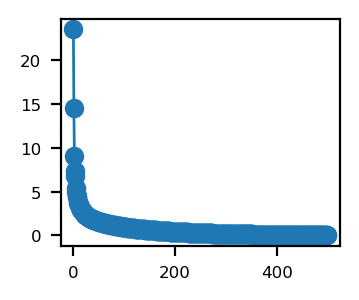

In [128]:
u, s, v = np.linalg.svd(mat)

plt.figure()
plt.plot(s, marker='o')
# plt.xlim(0, 100)
# plt.xscale('log')
# plt.yscale('log')

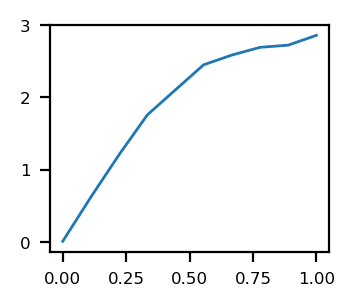

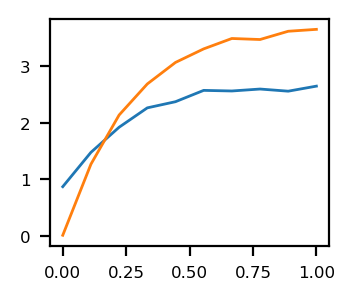

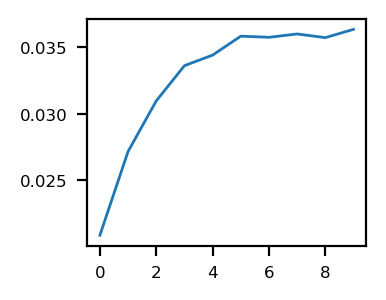

In [118]:
plt.figure()
plt.plot(permutations, traces)

plt.figure()
plt.plot(permutations, trace1, label='r12 trace')
plt.plot(permutations, trace2, label='I - r21 trace')
# plt.xlim(0, 1)

plt.figure()
plt.plot(norm1)

In [129]:
plt.figure()

<Figure size 360x300 with 0 Axes>

<Figure size 360x300 with 0 Axes>

Text(0, 0.5, 'imag')

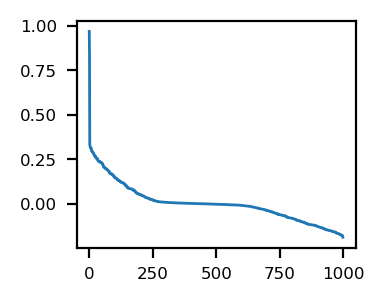

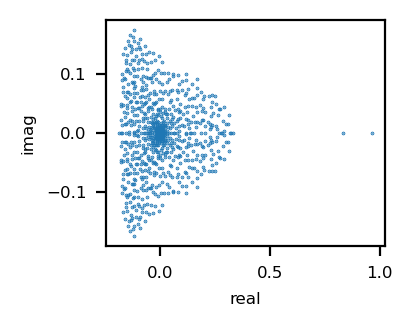

In [138]:
R_avg = (R12 + R21 + R13 + R32 + R14 + R42 + R43) / 7
# q, v = torch.linalg.eig(torch.eye(P) - R_avg)
# plt.figure()
# plt.plot(np.sort(torch.real(q))[::-1])


q, v = torch.linalg.eig(R_avg)
plt.figure()
plt.plot(np.sort(torch.real(q))[::-1])

plt.figure()
plt.scatter(torch.real(q), torch.imag(q), s=0.1)
plt.xlabel('real')
plt.ylabel('imag')
# plt.xscale('log')
# plt.yscale('log')

In [67]:
vectors = torch.normal(torch.zeros((1000, P)))
avg_loss = torch.zeros(10)
for i in range(10):
    avg_loss[i] = torch.norm((-torch.matrix_power(torch.eye(P) - R_avg, i+1) + (torch.eye(P) - R_avg) + torch.eye(P)) @ vectors.t())**2

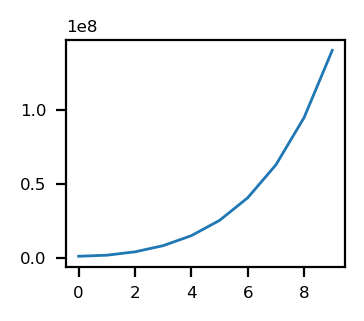

In [68]:
plt.figure()
plt.plot(avg_loss)

In [2]:

P_vals = np.arange(100, 3000, 300)
from matplotlib.pyplot import cm
cmap = cm.coolwarm(P_vals / P_vals.max())
overlaps = np.zeros((len(P_vals), 10))
for i, _P in enumerate(P_vals):
    seq_of_train_x, _, _, _ = \
        data.prepare_sequential_dataset(2, _P, P_test, dataset_name=dataset,
                                        resample=resample, permutation=permutation,
                                        data_path=None, n_epochs=n_epochs)
    for _depth in range(10):
        R12 = r_ab(1, 2, _depth + 1)
        overlaps[i, _depth] = torch.trace(R12.T @ R12) / _P


/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


Text(0.5, 1.0, 'mnist,permute=1')

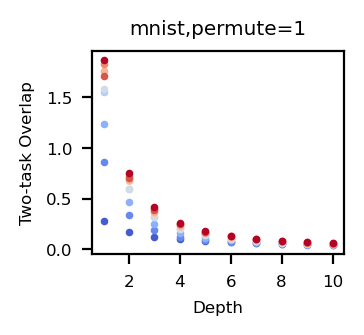

In [3]:
plt.figure()
for i in range(len(P_vals)):
    plt.scatter(np.arange(1, 11), overlaps[i], color=cmap[i], s=3)
plt.xlabel('Depth')
plt.ylabel('Two-task Overlap')
plt.tight_layout()
plt.title(f'{dataset},permute={permutation}')
# plt.colorbar(cmap)

In [485]:


# lamb_values = np.linspace(50, 2000, 30)

torch.manual_seed(SEED)

seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
    data.prepare_sequential_dataset(n_tasks, P, P_test, dataset_name=dataset, resample=resample, permutation=permutation, data_path=None, n_epochs=n_epochs)

seq_of_train_y_onehot = [data.digit_to_onehot(digit) for digit in seq_of_train_y_digit]
seq_of_test_y_onehot = [data.digit_to_onehot(digit) for digit in seq_of_test_y_digit]

x1 = seq_of_train_x[0]
x2 = seq_of_train_x[1]
Y2_all_heads = seq_of_train_y_onehot[1][:, :]
Y1_all_heads = seq_of_train_y_onehot[0][:, :]

# write f_2(x1)=k_12 K_2^-1 Y_2 + Y_1 - K12 K2^-1 K21 K1^-1 Y1
# call these term1 term2 term3

term1_norms = np.zeros((6, 10))
term3_norms = np.zeros((6, 10))
term1_plus_term3_norms = np.zeros((6, 10))
term1_plus_term3_angles = np.zeros((6, 10))
matrix_norms = np.zeros((6))
matrix_nuclear_norms = np.zeros((6))
losses = np.zeros((6, 10))
all_r12s = np.zeros((6, P, P))
for depth_ind in range(6):
    K12 = theory.arccos_kernel_deep(x1, x2, depth=depth_ind + 1, var1=torch.ones(1))
    K2 = theory.arccos_kernel_deep(x2, x2, depth=depth_ind + 1, var1=torch.ones(1))
    K1 = theory.arccos_kernel_deep(x1, x1, depth=depth_ind + 1, var1=torch.ones(1))

    K1_inv = theory.inverse(K1)
    K2_inv = theory.inverse(K2)
    all_r12s[depth_ind] = K12 @ K2_inv
    matrix_norms[depth_ind] = np.linalg.norm(torch.eye(P) - K12 @ K2_inv)
    matrix_nuclear_norms[depth_ind] = np.linalg.norm(K12 @ K2_inv, ord='nuc')

    for head_ind in range(10):
        term1 = K12 @ K2_inv @ Y2_all_heads[:, head_ind, :]
        term3 = K12 @ K2_inv @ K12.T @ K1_inv @ Y1_all_heads[:, head_ind, :]
        term1_norms[depth_ind, head_ind] = torch.norm(term1)**2 / P
        term3_norms[depth_ind, head_ind] = torch.norm(term3)**2 / P
        term1_plus_term3_norms[depth_ind, head_ind] = \
         torch.norm(term3 + term1)**2 / P
        term1_plus_term3_angles[depth_ind, head_ind] = \
            utils.cos((term3 + term1).numpy().flatten(), Y1_all_heads[:, head_ind, :].numpy().flatten())



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


KeyboardInterrupt: 

tensor(22.0324) tensor(33.0469)


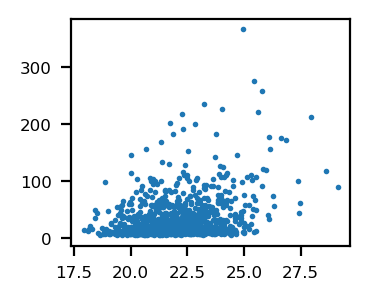

In [27]:
unit_vecs = torch.normal(torch.zeros((1000, P)))
# unit_vecs /= torch.norm(unit_vecs, dim=1)

vec1 = unit_vecs @ (torch.eye(P) - R21).T
vec2 = unit_vecs @ (torch.eye(P) - R21).T @ R12.T

sq_norm1 = torch.norm(vec1, dim=1)**2
sq_norm2 = torch.norm(vec2, dim=1)**2

trace = torch.trace(R12.T @ R12)
sq_norm1 *= trace / P

plt.figure()
plt.scatter(sq_norm1, sq_norm2, s=1)

print(sq_norm1.mean(), sq_norm2.mean())

In [78]:
downward_proj = torch.normal((torch.zeros((1000, 10))))
proj_mat = downward_proj @ downward_proj.T
x1 = torch.normal(torch.zeros((P, 1000))) @ downward_proj + 10000
x1 /= torch.norm(x1)
x2 = torch.normal(torch.zeros((P, 1000))) @ downward_proj + 10000
x2 /= torch.norm(x2)
r12 = x1 @ x2.T @ torch.inverse(x2 @ x2.T)
r21 = x2 @ x1.T @ torch.inverse(x1 @ x1.T)
mat = r12 @ (torch.eye(P) - r21)
print(torch.trace(mat.T @ mat) / P)




tensor(4.9172e+12)


# Cosine angle between data points

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x /= torch.norm(x, dim=1).reshape(-1, 1) / math.sqrt(x.shape[1])
  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 10/10 [00:00<00:00, 91.46it/s]


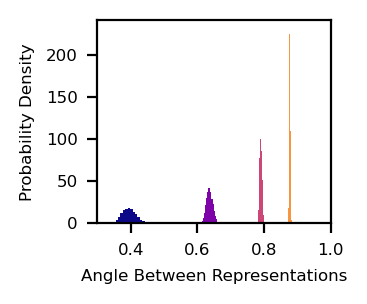

In [108]:
x, preds, y = get_simple_dataset(2, 100, 'mnist', resample=False, permutation=1)

plt.figure()
cmap = cm.plasma(np.arange(4) / 4)
for i, depth in enumerate([1, 3, 6, 10]):
    k12 = theory.arccos_kernel_deep(x[0], x[1], var1=torch.ones(1), depth=depth)
    k11 = theory.arccos_kernel_deep(x[0], x[0], var1=torch.ones(1), depth=depth)

    plt.hist((k12.flatten() / k11[0, 0]).numpy(), bins=20, color=cmap[i], density=True)
plt.xlabel('Angle Between Representations')
plt.ylabel('Probability Density')
plt.xlim(0.3, 1)
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

# Span analysis

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 10/10 [00:00<00:00, 16.12it/s]


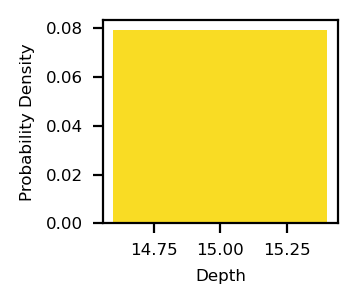

In [128]:
x, preds, y = get_simple_dataset(2, 1000, 'mnist', resample=False, permutation=1)

plt.figure()
cmap = cm.plasma(np.arange(15) / 15)

forgetting = []

coefs = []
for _depth in range(1, 16):
    k12 = theory.arccos_kernel_deep(x[0], x[1], var1=torch.ones(1), depth=_depth)
    k1 = theory.arccos_kernel_deep(x[0], x[0], var1=torch.ones(1), depth=_depth)
    k2 = theory.arccos_kernel_deep(x[1], x[1], var1=torch.ones(1), depth=_depth)

    u, s, v = torch.svd(k1)

    mat = k12 @ theory.inverse(k2) @ (torch.eye(1000) - k12.T @ theory.inverse(k1))
    forgetting.append(torch.norm(mat @ y[:, 0])**2)

    coefs.append(torch.trace(mat.T @ mat))

    k1_half_inv = u @ torch.diag((s + 1e-10)**-0.5) @ v.T
    span_overlap = k1_half_inv @ k12 @ theory.inverse(k2) @ k12.T @ k1_half_inv
    plt.bar(i + 1, torch.trace(span_overlap) / 1000, color=cmap[i])
    # plt.bar(i + 1, torch.trace(k1), color=cmap[i])

    # plt.hist((span_overlap).flatten().numpy(), bins=20, color=cmap[i], density=True)
plt.xlabel('Depth')
plt.ylabel('Probability Density')
# plt.xlim(0.3, 1)
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')

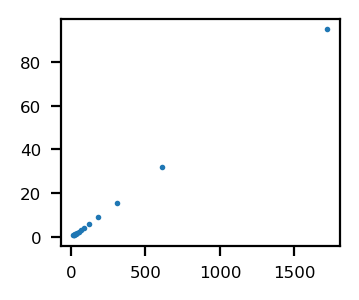

In [129]:
plt.figure()
plt.scatter(coefs, forgetting, s=1)

In [130]:
baselines = [0.08276906811505587,
 0.04066070052551703,
 0.029109533739369878,
 0.02436525020266907]

time_constants = [3.8745317423476613, 7.048772919183998, 11.471618228076993, 16.63216881203696]

Text(0, 0.5, '1 / tau')

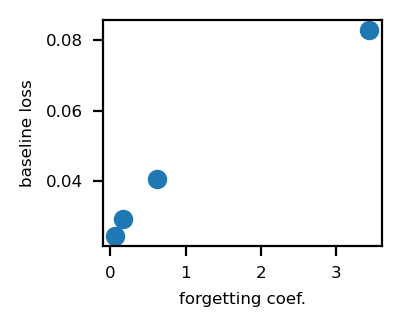

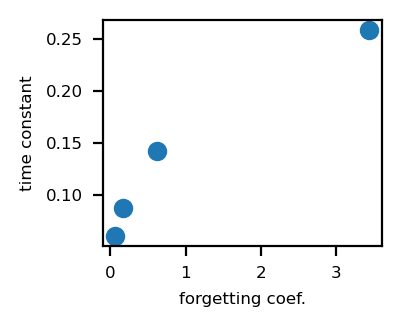

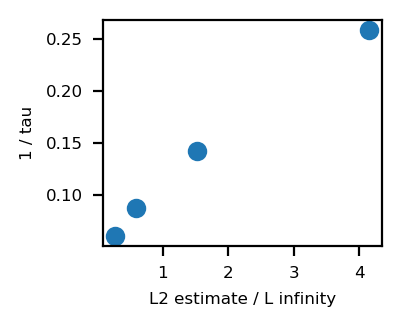

In [136]:
coef_13610 = [coefs[0] / P, coefs[2] / P, coefs[5] / P, coefs[9] / P]
plt.figure()
plt.scatter(coef_13610, baselines)
plt.xlabel('forgetting coef.')
plt.ylabel('baseline loss')


plt.figure()
plt.scatter(coef_13610, 1 / np.array(time_constants))
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('forgetting coef.')
plt.ylabel('time constant')


plt.figure()
plt.scatter(np.array(coef_13610) / 10 / np.array(baselines), 1 / np.array(time_constants))
plt.xlabel('L2 estimate / L infinity')
plt.ylabel('1 / tau')

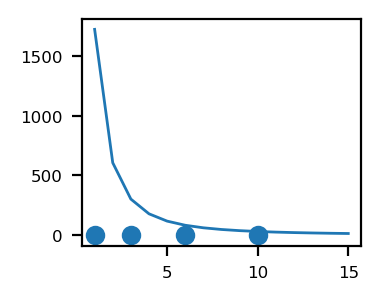

In [110]:
plt.figure()
plt.plot(np.arange(1, 16), coefs)

plt.scatter([1, 3, 6, 10], [.68, .83, .89, .93])

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
100%|██████████| 10/10 [00:00<00:00, 29.66it/s]


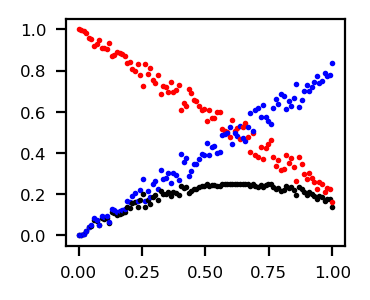

In [71]:
all_x, predictions, _ =\
    get_simple_dataset(1, P, dataset='mnist', resample=False, permutation=1)
strengths = np.linspace(0, 1, 100)
a = all_x.flatten()[:784]
a[a < 0] = 0
plt.figure()
for i in range(100):
    cosine = utils.cos(a, a @ utils.get_permutation_mat(784, strength=strengths[i]))
    plt.scatter(strengths[i], cosine @ (1 - cosine), color='k', s=1)
    plt.scatter(strengths[i], cosine, color='r', s=1)
    plt.scatter(strengths[i], 1 - cosine, color='b', s=1)

In [139]:
all_x.shape

torch.Size([5, 500, 784])

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
  0%|          | 0/10 [00:00<?, ?it/s]/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:320: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')
  0%|          | 0/10 [00:01<?, ?it/s]


KeyboardInterrupt: 

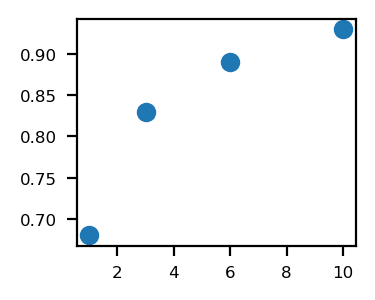

In [148]:
plt.scatter([1, 3, 6, 10], [.68, .83, .89, .93])


In [182]:
_v.shape

torch.Size([2000, 1000])

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()


(0.0, 1.1)

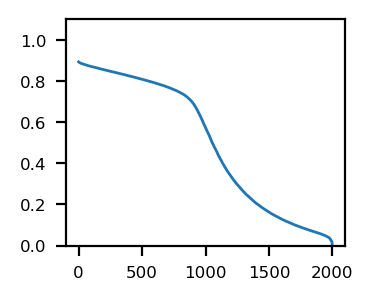

In [186]:
N = 2000
NUM_AVG = 50
all_x =\
    get_simple_dataset(NUM_AVG, 1000, dataset='mnist', resample=False, permutation=1, only_x=True)

W = torch.normal(torch.zeros((784, N))) / np.sqrt(N)

all_X = all_x @ W


avg = torch.zeros((N, N))
for i in range(NUM_AVG):
    _u, _, _v = torch.svd(all_X[i])
    avg += _v @ _v.T / NUM_AVG


mat = torch.eye(N) - avg

u, s, v = torch.svd(mat)

plt.figure()
plt.plot(s)
plt.ylim(0, 1.1)